In [1]:
import pandas as pd
import numpy as np
import commodity_common_functions as CCF
import seaborn as sns
import dataframe_image as dfi
from pathlib import Path
import json
import seaborn as sns
import datetime as dt
import logging
from datetime import datetime
import os
import OptionRiskMetrixETF as ORME
import OptionRiskMetrix as ORM
import RiskManagementSystem as RMS
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

In [2]:
def findLastFuturePrice(future, trading_date):
    trading_date = trading_date[:4] + '-' + trading_date[4:6] + '-' + trading_date[6:]
    sql_cmd = f'''
    SELECT trading_date, close
    FROM daily_data WHERE instrument_id='{future}' AND trading_date < '{trading_date}'
    '''
    df = pd.read_sql(sql_cmd, con=CCF.std_market_data)
    return df.iloc[-1]['close']

### 创建rollTable
def createMainTable(product_id):
    SQL_cmd = f"""
    WITH ranked_data AS (
        SELECT 
            instrument_id, 
            trading_date, 
            close, 
            volume, 
            open_interest,
            ROW_NUMBER() OVER (PARTITION BY trading_date ORDER BY volume DESC) as volume_rank,
            ROW_NUMBER() OVER (PARTITION BY trading_date ORDER BY open_interest DESC) as oi_rank
        FROM daily_data
        WHERE product_id = '{product_id}' and trading_date > '2021-09-01'
    ),
    ins_v1 AS (
        SELECT trading_date, instrument_id as ins_v1, close
        FROM ranked_data
        WHERE volume_rank = 1
    ),
    ins_oi1 AS (
        SELECT trading_date, instrument_id as ins_oi1
        FROM ranked_data
        WHERE oi_rank = 1
    )
    SELECT 
        v.trading_date,
        v.ins_v1,
        v.close,
        oi.ins_oi1
    FROM ins_v1 v
    JOIN ins_oi1 oi ON v.trading_date = oi.trading_date
    ORDER BY v.trading_date
    """
    info = pd.read_sql(sql=SQL_cmd, con=CCF.std_market_data)
    info['both1'] = info['ins_v1'].where(info['ins_v1'] == info['ins_oi1'], other=np.nan)
    # Initialize main_id column
    info['main_id'] = ''
    info.loc[0, 'main_id'] = info.loc[0, 'ins_oi1']

    # Iterate through rows to update main_id based on conditions
    for i in range(1, len(info)):
        current_main_id = info.loc[i-1, 'main_id']
        both1_value = info.loc[i, 'both1']
        current_oi = info.loc[i, 'ins_oi1']
        
        if pd.notna(both1_value) and both1_value > current_main_id:
            new_main_id = both1_value
        else:
            # Check if we need to switch based on last 3 rows condition
            if i >= 3:
                # Check if current_main_id is not both1_value for the last 3 rows
                last_3_both1 = [info.loc[j, 'both1'] for j in range(i-2, i+1)]
                last_3_oi = [info.loc[j, 'ins_oi1'] for j in range(i-2, i+1)]
                
                # Check if current_main_id is not in the last 3 both1_values (all are NaN or different)
                current_main_not_in_both1 = all(pd.isna(val) or val != current_main_id for val in last_3_both1)
                
                # Check if ins_oi1 is the same for last 3 rows
                oi_same_for_3 = len(set(last_3_oi)) == 1
                
                # Check if current_main_id is greater than ins_oi1
                current_main_greater = current_oi > current_main_id 
                
                if current_main_not_in_both1 and oi_same_for_3 and current_main_greater:
                    new_main_id = current_oi
                else:
                    new_main_id = current_main_id
            else:
                new_main_id = current_main_id
                
        info.loc[i, 'main_id'] = new_main_id
    info['trading_date'] = info['trading_date'].str.replace('-', '')
    return info.iloc[1:,:][['trading_date','main_id','close']]


def futureQuote(underlying, tradingdate):
    path = f"G:\\quoteData\\{tradingdate}\\{underlying}.csv"
    if(os.path.isfile(path)):
        return pd.read_csv(path, dtype={'id': str})
    print(f'no {underlying} quote file exist in date {tradingdate}, creating...')
    try:
        last_day_close = findLastFuturePrice(underlying, tradingdate)
        future_path = CCF.Ftp_Path(tradingdate)
        future_path = f'{future_path}ctp_std_data/{tradingdate}/{underlying}.csv'
        FutureData = pd.read_csv(future_path, usecols=['id', 'seq_no', 'bid_price1', 'ask_price1', 'last_price','turnover','volume','open_interest'],
                                 dtype={'id': object, 'seq_no': np.int64, 'bid_price1': np.float64,
                                        'ask_price1': np.float64,'last_price': np.float64},
                                 escapechar='/', na_values=r"\N")
        ### 新加入清洗数据逻辑
        volcummax = FutureData['volume'].cummax()
        FutureData = FutureData[FutureData['volume'] >= volcummax]
        # FutureData.loc[:, 'FutureMidPrice'] = 0.5 * (FutureData['bid_price1'] + FutureData['ask_price1'])
        # 考虑无ask/bid报价的场景，如涨跌停
        FutureData.rename(columns={'bid_price1': 'FutureBid1', 'ask_price1': 'FutureAsk1'}, inplace=True)
        FutureData['Updatetime'] = FutureData['id'].apply(lambda x: f'{x[8:10]}:{x[10:12]}')
        FutureData.loc[:, 'FutureMidPrice'] = FutureData.apply(lambda row: row['last_price'] if row["FutureBid1"] * row["FutureAsk1"] == 0 else 0.5*(row["FutureBid1"]+row["FutureAsk1"]), axis=1)
        FutureData_df = FutureData.groupby('Updatetime').head(1).copy()
        FutureData_df['MaxPrice'] = FutureData.groupby('Updatetime').max().sort_values(by = 'seq_no')['FutureMidPrice'].values
        FutureData_df['MinPrice'] = FutureData.groupby('Updatetime').min().sort_values(by = 'seq_no')['FutureMidPrice'].values
        FutureData_df['minute_variance'] = np.square(np.log(FutureData_df['FutureMidPrice']/FutureData_df['FutureMidPrice'].shift()))
        FutureData_df.reset_index(inplace = True,drop=True)
        crossday_variance = np.square(np.log(FutureData_df.iloc[0]['FutureMidPrice']/last_day_close))
        FutureData_df.loc[0,'minute_variance'] = crossday_variance
        Path(f"G:\\quoteData\\{tradingdate}").mkdir(parents=True, exist_ok=True)
        FutureData_df.to_csv(path)
        return FutureData_df
    except Exception as e:
        print(underlying, tradingdate, 'futureinfo error')
        raise e 

In [3]:
# def generateMinTable(product_id):
#     SQL_cmd = f"""
#     SELECT trading_date, main_id, close
#     FROM main_table
#     WHERE product_id = '{product_id}'
#     """
#     return pd.read_sql(sql=SQL_cmd, con=CCF.std_market_data)
otrdf = createMainTable('SA')
error_lst = []
mindf = pd.DataFrame()
for ind, row in otrdf.iterrows():
    date = row['trading_date']
    future = row['main_id']
    todayclose = row['close']
    try:
        last_day_close = findLastFuturePrice(future, date)
        # print(future, date, last_day_close)
        thsiquote = futureQuote(future, date)[['id','last_price','volume', 'turnover', 'open_interest']]
        thsiquote.loc[thsiquote.index[-1], 'last_price'] = todayclose
        thsiquote['trading_date'] = date
        thsiquote['main_id'] = future
        thsiquote['timestamp'] = pd.to_datetime(thsiquote['id'].str[:8] + ' ' + thsiquote['id'].str[8:10] + ':' + thsiquote['id'].str[10:12] + ':' + thsiquote['id'].str[12:14])
        thsiquote = thsiquote.drop(columns=['id'])
        thsiquote['lnret'] = np.log(thsiquote['last_price']/thsiquote['last_price'].shift())
        thsiquote.loc[0, 'lnret'] = np.log(thsiquote.loc[0, 'last_price']/last_day_close)
        thsiquote['ret'] = thsiquote['last_price']/thsiquote['last_price'].shift()-1
        thsiquote.loc[0, 'ret'] = thsiquote.loc[0, 'last_price']/last_day_close-1
        thsiquote['dvol'] = thsiquote['volume'].diff()
        thsiquote.loc[0, 'dvol'] = thsiquote.loc[0, 'volume']
        mindf = pd.concat([mindf, thsiquote])
    except Exception as e:
        print(future, date, 'futureQuote error:', e)
        error_lst.append([future, date])

no SA509 quote file exist in date 20250801, creating...


In [4]:
# Convert 1-minute data to 15-minute bars
sample = mindf.copy().reset_index(drop=True)
sample['timestamp_15min'] = sample['timestamp'].dt.ceil('15T')
sample_15min = sample.groupby(['trading_date', 'main_id', 'timestamp_15min']).agg({
    'last_price': 'last',  # Take the last price in each 15-minute period
    'volume': 'last',      # Take the last volume
    'turnover': 'last',    # Take the last turnover
    'open_interest': 'last',  # Take the last open_interest
    'lnret': 'sum',        # Sum of log returns
    'ret': lambda x: (1 + x).prod() - 1,  # Compound returns
    'dvol': 'sum'          # Sum of volume changes
}).reset_index()
sample_15min = sample_15min.rename(columns={'timestamp_15min': 'timestamp'})

C:\Users\zhs\AppData\Local\Temp\ipykernel_15944\2398589059.py:3: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  sample['timestamp_15min'] = sample['timestamp'].dt.ceil('15T')


In [34]:
sample = sample_15min
day_minlen = len(sample[sample['trading_date'] == sample['trading_date'].iloc[0]])
day_15minlen = len(sample_15min[sample_15min['trading_date'] == sample_15min['trading_date'].iloc[0]])
sample['rv'] = np.sqrt(np.square(sample['lnret']).rolling(window=day_15minlen*30).sum()/30*243)
# days = 1
# total_len = day_15minlen*days
# sample['rvdiscretesum'] = np.square(sample['lnret']).rolling(window=total_len).sum()
# sample['crsoss'] = np.square(sample['lnret'].rolling(window=total_len).sum())
# sample['rvsrvdiff'] = sample['crsoss'] - sample['rvdiscretesum']

In [30]:
# short_T = 1
# med_T = 5
long_T = 5
# sample['rvsrvdiff_short'] = np.square(sample['lnret'].rolling(window=day_15minlen*short_T).sum()) - np.square(sample['lnret']).rolling(window=day_15minlen*short_T).sum()
# sample['rvsrvdiff_med'] = np.square(sample['lnret'].rolling(window=day_15minlen*med_T).sum()) - np.square(sample['lnret']).rolling(window=day_15minlen*med_T).sum()
sample['rvsrvdiff_long'] = np.square(sample['lnret'].rolling(window=day_15minlen*long_T).sum()) - np.square(sample['lnret']).rolling(window=day_15minlen*long_T).sum()

# Calculate rolling t-stats for each rvsrvdiff series with corresponding window
def rolling_tstat(series, window):
    roll_mean = series.rolling(window=window).mean()
    roll_std = series.rolling(window=window).std(ddof=0)
    return roll_mean / (roll_std / np.sqrt(window))

# sample['rvsrvdiff_short_tstat'] = rolling_tstat(sample['rvsrvdiff_short'], day_15minlen*short_T)
# sample['rvsrvdiff_med_tstat'] = rolling_tstat(sample['rvsrvdiff_med'], day_15minlen*med_T)
sample['rvsrvdiff_long_tstat'] = rolling_tstat(sample['rvsrvdiff_long'], day_15minlen*long_T)
# Vectorized calculation of rvsrvdiff_score without iteration
score = (
    # (sample['rvsrvdiff_short_tstat'] > 2).astype(int) - (sample['rvsrvdiff_short_tstat'] < -2).astype(int) +
    # (sample['rvsrvdiff_med_tstat'] > 2).astype(int) - (sample['rvsrvdiff_med_tstat'] < -2).astype(int) +
    (sample['rvsrvdiff_long_tstat'] > 2).astype(int) 
)
sample['rvsrvdiff_score'] = score


# Yes, you can use rolling().apply() with a custom function, as in the original code.
# However, for rolling().apply(), your function will receive a DataFrame (if you specify multiple columns) or a Series (if you specify a single column).
# Here is a version that is explicit about the columns used, and works with rolling().apply():

def calculate_piv(x):
    # x is a DataFrame with columns 'ret' and 'last_price'
    if(len(x) < day_15minlen*long_T):
        return np.nan
    ret_lst = x['ret'][::-1].values + 1
    ret_lst = np.concatenate(([1], ret_lst[:-1]))
    slst = x['last_price'].iloc[-1] / np.cumprod(ret_lst)
    return float(len(slst) / (1 / slst).sum())


for ind, row in sample.iterrows():
    if(ind < day_15minlen*long_T):
        sample.loc[ind, 'piv_long'] = np.nan
    else:
        subset = sample.iloc[ind-day_15minlen*long_T:ind+1]
        sample.loc[ind, 'piv_long'] = calculate_piv(subset)


In [38]:
(sample['ret'] + 1).rolling(window=day_15minlen*long_T).apply(np.prod, raw=True)

0             NaN
1             NaN
2             NaN
3             NaN
4             NaN
           ...   
25537    0.874126
25538    0.873515
25539    0.865184
25540    0.869958
25541    0.872222
Name: ret, Length: 25542, dtype: float64

In [31]:
sample['std_dg'] = 10000/(np.square(sample['rv'])*long_T/243)
sample['dg'] = sample['std_dg']*sample['rvsrvdiff_score']
sample['dollarexposure'] = 2 * sample['dg'] * (sample['last_price']/sample['piv_long']-1)
sample['ddollarret'] = sample['dollarexposure'].shift()*sample['ret']
sample['cumdollarret'] = sample['ddollarret'].cumsum()


<Axes: >

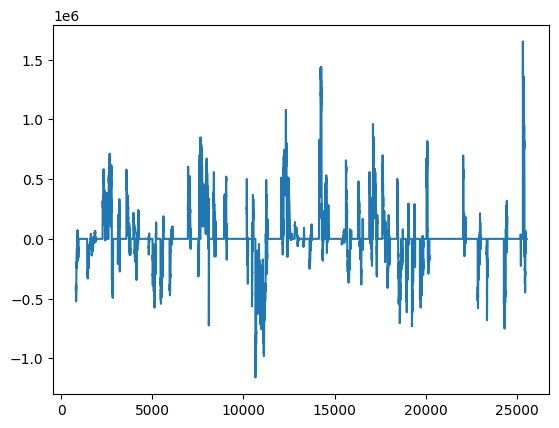

In [32]:
sample['dollarexposure'].plot()

<Axes: >

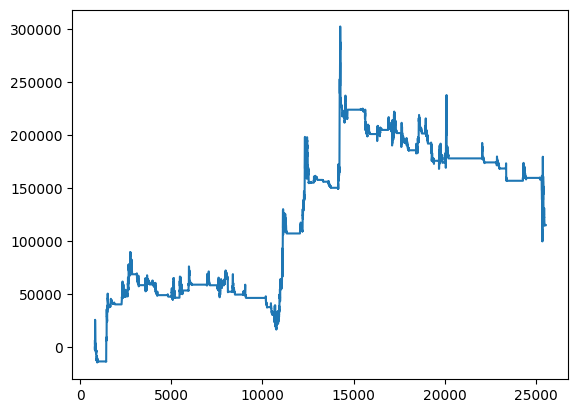

In [33]:
sample['cumdollarret'].plot()

In [27]:
def calculate_piv(x):
    ret_lst = x['ret'][::-1].values+1
    ret_lst = np.concatenate(([1], ret_lst[:-1]))
    slst = x.iloc[-1]['last_price']/np.cumprod(ret_lst)
    return float(len(slst)/(1/slst).sum())


In [ ]:
68280.0/1.137

<Axes: >

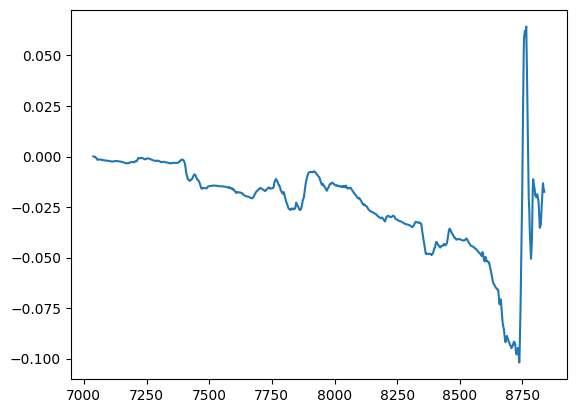

In [16]:
sample['rvsrvdiff'].tail(day_15minlen*100).cumsum().plot()

In [ ]:
# def generateCTAtable(dollargamma, piv_price):
#     tick = 1 
#     multi = 1
#     ds = 0.0005*piv_price
#     up_lst = [[piv_price, 0, dollargamma*2/piv_price/piv_price]]
#     down_lst = [[piv_price, 0, dollargamma*2/piv_price/piv_price]]
#     for i in range(1000):
#         price, delta, gamma = up_lst[-1]
#         new_price = price + ds
#         new_gamma = dollargamma*2/new_price/new_price
#         new_delta = delta + ds * gamma
#         up_lst.append([new_price, new_delta, new_gamma])
#         price, delta, gamma = down_lst[-1]
#         new_price = price - ds
#         new_gamma = dollargamma*2/new_price/new_price
#         new_delta = delta - ds * gamma
#         down_lst.append([new_price, new_delta, new_gamma])
#     deltaTable = pd.DataFrame(down_lst[::-1][:-1]+up_lst, columns = ['und_price','delta','gamma'])
#     # deltaTable.to_csv('2.csv')
#     y_interp = interp1d(deltaTable['und_price'], deltaTable['delta'])
#     return y_interp
#     max_price = deltaTable['und_price'].max()
#     min_price = deltaTable['und_price'].min()
#     gmmtable = []
#     curr_price = int(min_price/tick) * tick + tick
#     terminal_price = int(max_price/tick) * tick - tick
#     while(curr_price <  terminal_price):
#         delta = y_interp(curr_price)
#         pos = int(round(delta/multi))
#         gmmtable.append([curr_price,pos, abs(delta-pos*multi)])
#         curr_price += tick
#     ## 初始表格为VSP delta Replicate,追涨杀跌
#     oriGMM = pd.DataFrame(gmmtable, columns = ['price','volume','error'])
#     oriGMM = oriGMM.sort_values('error').groupby('volume').head(1).sort_values('volume').reset_index(drop=True)[['price','volume']]
#     return oriGMM

# class DG:
#     def __init__(self, g, s0):
#         self.g = g
#         self.s0 = s0
#     def yint(self, s):
#         return 2*self.g * (1/self.s0-1/s)
    
# import numpy as np
# import pandas as pd

# # Generate a random time series with length beginning with 100
# # np.random.seed(42)  # For reproducibility
# time_series_length = 10000
# # random_time_series = np.random.randn(time_series_length)/100
# random_time_series = [0,8,12]

# # Create a DataFrame with the time series
# time_series_df = pd.DataFrame({
#     'time_index': range(len(random_time_series)),
#     'value': random_time_series
# })
# time_series_df['price'] = time_series_df['value'].cumsum() + 100
# time_series_df.loc[0, 'price'] = 100  # Set first value to exactly 100
# dg = 10000
# s0 = 100
# time_series_df['delta'] = 2 * dg * (1/s0 - 1/time_series_df['price'])
# time_series_df['dollar'] = 2 * dg * (time_series_df['price']/s0 - 1)
# time_series_df['dret1'] = time_series_df['price'].diff() * time_series_df['delta'].shift()
# time_series_df['dret2'] = time_series_df['price'].pct_change() * time_series_df['dollar'].shift()
# time_series_df['ret'] = time_series_df['dret1'].cumsum()

# crossrv = np.square(np.log(time_series_df.iloc[-1]['price']/time_series_df.iloc[0]['price']))
# drv = np.square(np.log(time_series_df['price']/time_series_df['price'].shift()))
# print((crossrv-drv.sum())*dg)
# print(time_series_df['dret1'].sum())
    
# total_dg = 10000
# s0list = [101,102,103,104,105,106,107,108,109,110]
# s = 130
# ds = 0
# for s0 in s0list:
#     thisdg = total_dg/len(s0list)
#     ds += DG(thisdg,s0).yint(s)
# ds



162.17309959331294
177.77777777777794


In [4]:
futureQuote('ao2311', '20230619')

no ao2311 quote file exist in date 20230619, creating...
ao2311 20230619 futureinfo error


IndexError: single positional indexer is out-of-bounds

In [7]:
error_lst = []
total_prodset = ['a', 'ag', 'al', 'ao', 'AP', 'au', 'br', 'bu', 'c',
       'CF', 'CJ', 'cs', 'cu', 'eb', 'ec', 'eg', 'FG', 'fu', 'hc', 'i',
       'IC', 'IF', 'IH', 'IM', 'j', 'jd', 'jm', 'l', 'lc', 'lh', 'm',
       'MA', 'ni', 'nr', 'OI', 'p', 'pb', 'PF', 'pg', 'PK', 'pp', 'PR',
       'ps', 'PX', 'rb', 'RM', 'ru', 'SA', 'sc', 'SF', 'SH', 'si', 'SM',
       'sn', 'sp', 'SR', 'ss', 'T', 'TA', 'TF', 'TL', 'TS', 'UR', 'v',
       'y', 'zn']
for prod in total_prodset:
    otrdf = createMainTable(prod)
    for ind, row in otrdf.iterrows():
        date = row['trading_date']
        future = row['main_id']
        try:
            futureQuote(future, date)
        except:
            print(future, date, 'futureQuote error')
            error_lst.append([future, date])
            # print(error_lst)
            continue



no a2509 quote file exist in date 20250730, creating...
no ag2510 quote file exist in date 20250730, creating...
no al2509 quote file exist in date 20250730, creating...
no ao2509 quote file exist in date 20250730, creating...
no AP510 quote file exist in date 20250730, creating...
no au2510 quote file exist in date 20250730, creating...
no br2509 quote file exist in date 20250730, creating...
no bu2509 quote file exist in date 20250730, creating...
no c2509 quote file exist in date 20250730, creating...
no CF509 quote file exist in date 20250730, creating...
no CJ601 quote file exist in date 20250730, creating...
no cs2509 quote file exist in date 20250730, creating...
no cu2509 quote file exist in date 20250730, creating...
no eb2509 quote file exist in date 20250730, creating...
no ec2510 quote file exist in date 20250730, creating...
no eg2509 quote file exist in date 20250730, creating...
no FG509 quote file exist in date 20250730, creating...
no fu2509 quote file exist in date 20

In [8]:
a = pd.DataFrame(error_lst)
a

,0,1
0,ni2204,20220310


In [35]:
# SQL_cmd = f"""
# SELECT distinct product_id, max(volume) as volume
# FROM daily_data
# WHERE trading_date = '2025-07-25'
# GROUP BY product_id
# """
# total_prodset = pd.read_sql(sql=SQL_cmd, con=CCF.std_market_data)
total_prodset = ['a', 'ag', 'al', 'ao', 'AP', 'au', 'br', 'bu', 'c',
       'CF', 'CJ', 'cs', 'cu', 'eb', 'ec', 'eg', 'FG', 'fu', 'hc', 'i',
       'IC', 'IF', 'IH', 'IM', 'j', 'jd', 'jm', 'l', 'lc', 'lh', 'm',
       'MA', 'ni', 'nr', 'OI', 'p', 'pb', 'PF', 'pg', 'PK', 'pp', 'PR',
       'ps', 'PX', 'rb', 'RM', 'ru', 'SA', 'sc', 'SF', 'SH', 'si', 'SM',
       'sn', 'sp', 'SR', 'ss', 'T', 'TA', 'TF', 'TL', 'TS', 'UR', 'v',
       'y', 'zn']
